<a href="https://colab.research.google.com/github/mp3fbf/now/blob/main/Authors_03_Cluster_Dados_Emero_Bancada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#<font color = "tomato">Cluster Analysis</font>

##<font color = "seagreen">Libraries</font>

In [ ]:
# Install required libraries
# !pip install -q gdown openpyxl

# Import the libraries

import gdown
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import skew, kurtosis
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind, mannwhitneyu, f_oneway, kruskal, shapiro
from scipy.stats import chi2_contingency
from statsmodels.graphics.mosaicplot import mosaic
import matplotlib.pyplot as plt



##<font color = "seagreen">Database Loading</font>

In [ ]:

# ===============================
# STEP 1: Define your file ID
# ===============================
# Replace this ID with the ID of your spreadsheet on Google Drive
file_id = '1detyGSWWAbJFLVmrGUG69WIsSa95WK04'
output_name = 'dados_emero_mai_2025.xlsx'

# ===============================
# STEP 2: Download the Excel file from Google Drive
# ===============================
download_url = f'https://drive.google.com/uc?id={file_id}'
gdown.download(download_url, output_name, quiet=False)

# ===============================
# STEP 3: Read the spreadsheet using pandas
# ===============================
# For multiple sheets, use: pd.read_excel(..., sheet_name='sheet_name')
df = pd.read_excel(output_name, engine='openpyxl')

# ===============================
# STEP 4: Display the first few rows of the spreadsheet
# ===============================
print("The first rows of the spreadsheet are:")
print(df.head())


Downloading...
From: https://drive.google.com/uc?id=1detyGSWWAbJFLVmrGUG69WIsSa95WK04
To: /content/dados_emero_mai_2025.xlsx
100%|██████████| 749k/749k [00:00<00:00, 112MB/s]


The first rows of the spreadsheet are:
     ID  Age     Sex  NeuroAC  RR  SatO2  HR  SAP  DAP     T  ...   Dplus  \
0   514   64  Female        1  15     95  70  167   90  36.4  ...  0.6811   
1   516   65  Female        1  15     96  64  128   84  36.4  ...  0.6607   
2   519   62  Female        1  15     97  88  100   62  36.4  ...  0.5255   
3   562   24  Female        1  15     99  80  100   58  36.4  ...  0.5261   
4  1601   48  Female        1  15     98  94  125   81  36.1  ...  0.5338   

   Dminus     Csi RankTOPSIS  PriorityColor StayMin  StayHour    TrailED  \
0  0.5860  0.4625      584.0          green      29      0.48  discharge   
1  0.5620  0.4596      561.0          green      26      0.43  discharge   
2  0.7076  0.5739     1358.0          green      91      1.52   returnED   
3  0.7121  0.5751     1362.0           blue     130      2.17   returnED   
4  0.6868  0.5627     1332.0         yellow     259      4.32   returnED   

   Hospitalization  ReturnED  
0         

##<font color = "seagreen">Data Quality Assessment of the Database</font>

In [ ]:
# ===============================
# STEP 1: Drop unwanted columns into a new DataFrame
# ===============================
columns_to_remove = ['ID', 'NeuroAC', 'RankTOPSIS', 'StayHour','Dminus', 'Dplus', 'ReturnED', "RR", "SatO2", "StayMin"]
df_drop = df.drop(columns=columns_to_remove, errors='ignore')

print("Remaining columns in df_drop:")
print(df_drop.head())

# ============================================
# STEP 2: Filter to patients aged 60 or older
# ============================================
df_cluster = df_drop[df_drop['Age'] >= 60].copy()

print(f"Retained {len(df_cluster )} patients aged 60 or older")

print(df_cluster.head())



Remaining columns in df_drop:
   Age     Sex  HR  SAP  DAP     T   PosMu Crtitically   NegNu      Risk  \
0   64  Female  70  167   90  36.4  0.3851        high  0.1772   veryLow   
1   65  Female  64  128   84  36.4  0.3887        high  0.2162       low   
2   62  Female  88  100   62  36.4  0.5153    moderate  0.1247   veryLow   
3   24  Female  80  100   58  36.4  0.5170    moderate  0.1192   veryLow   
4   48  Female  94  125   81  36.1  0.5302    moderate  0.4387  moderate   

   NeutralEta Uncertainty     Csi PriorityColor    TrailED Hospitalization  
0      0.4397         low  0.4625         green  discharge              no  
1      0.3970         low  0.4596         green  discharge              no  
2      0.3621         low  0.5739         green   returnED              no  
3      0.3659         low  0.5751          blue   returnED              no  
4      0.0332     veryLow  0.5627        yellow   returnED              no  
Retained 4157 patients aged 60 or older
   Age     

##<font color = "seagreen">Data Quality Audit</font>

In [ ]:
# ==========================================
# STEP 5: Data Quality Audit
# ==========================================

# 1. General information
print("\n📌 General Information of the DataFrame:")
print(f"Number of rows: {df_cluster.shape[0]}")
print(f"Number of columns: {df_cluster.shape[1]}")

# 2. Data types
print("\n📌 Data Types by Column:")
print(df_cluster.dtypes)

# 3. Missing values count
print("\n📌 Missing Values by Column (absolute and %):")
missing = df_cluster.isnull().sum()
missing_percent = (missing / df_cluster.shape[0]) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage (%)': missing_percent})
print(missing_df[missing > 0].sort_values(by='Percentage (%)', ascending=False))

# 4. Unique values and cardinality
print("\n📌 Cardinality (number of unique values) per column:")
print(df_drop.nunique().sort_values(ascending=False))

# 5. Constant columns (no variability)
print("\n📌 Constant Columns:")
constants = df_cluster.loc[:, df.nunique() == 1].columns.tolist()
print(constants if constants else "None")

# 6. Count of zeros in numeric columns
print("\n📌 Count of zero values in numeric columns:")
zero_counts = (df_cluster.select_dtypes(include=[np.number]) == 0).sum()
print(zero_counts[zero_counts > 0].sort_values(ascending=False))

# 7. Potentially misclassified columns (e.g., numeric as object)
print("\n📌 Columns with type 'object' that may contain non-text data (e.g., numbers or dates):")
for col in df_cluster.select_dtypes(include='object').columns:
    try:
        df_cluster[col].astype(float)
        print(f" - {col}: may contain numbers stored as text")
    except:
        pass

# 8. Basic statistics for numeric columns
print("\n📌 Basic Descriptive Statistics (numeric columns):")
display(df_cluster.describe(include=[np.number]).T.round(2))




📌 General Information of the DataFrame:
Number of rows: 4157
Number of columns: 16

📌 Data Types by Column:
Age                  int64
Sex                 object
HR                   int64
SAP                  int64
DAP                  int64
T                  float64
PosMu              float64
Crtitically         object
NegNu              float64
Risk                object
NeutralEta         float64
Uncertainty         object
Csi                float64
PriorityColor       object
TrailED             object
Hospitalization     object
dtype: object

📌 Missing Values by Column (absolute and %):
Empty DataFrame
Columns: [Missing, Percentage (%)]
Index: []

📌 Cardinality (number of unique values) per column:
Csi                3155
PosMu              3133
NegNu              2453
NeutralEta         1472
SAP                 154
HR                  112
DAP                  91
Age                  82
T                    20
Crtitically           5
PriorityColor         4
Risk                 

,count,mean,std,min,25%,50%,75%,max
Age,4157.0,72.36,7.48,60.00,66.00,72.00,78.00,99.00
HR,4157.0,82.56,15.24,25.00,72.00,81.00,92.00,200.00
SAP,4157.0,137.82,24.02,77.00,121.00,135.00,152.00,242.00
DAP,4157.0,76.81,12.06,42.00,69.00,76.00,83.00,166.00
T,4157.0,36.23,0.20,35.40,36.10,36.30,36.40,37.20
PosMu,4157.0,0.69,0.15,0.24,0.64,0.74,0.80,0.90
NegNu,4157.0,0.24,0.14,0.06,0.15,0.18,0.24,0.62
NeutralEta,4157.0,0.07,0.04,0.01,0.04,0.06,0.09,0.50
Csi,4157.0,0.75,0.16,0.31,0.70,0.81,0.87,1.05


#<font color = "tomato">Cluster Analysis</font>

##<font color = "seagreen">Libraries</font>

In [ ]:
# ============================================
# Install required libraries
# ============================================
# !pip install -q gdown openpyxl scikit-learn matplotlib seaborn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from google.colab import files
from sklearn.metrics import silhouette_score
from scipy.stats import zscore


##<font color = "seagreen">Standardization (Z-score)</font>

In [ ]:
# ============================================
# Standardize the data (Z-score)
# ============================================
features = ['SAP', 'DAP','PosMu', 'NegNu', 'NeutralEta', 'Csi']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[features])


##<font color = "seagreen">Outliers Treatment</font>

In [ ]:
# ============================================
# Outliers Treatment
# ============================================

# Outlier removal using Z-score
from scipy.stats import zscore
z_scores = np.abs(zscore(X_scaled))
mask_no_outliers = (z_scores < 3).all(axis=1)

# Filtered subsets
X_scaled_no_outliers = X_scaled[mask_no_outliers]


In [ ]:
# 1) Reconstruct the filtered DataFrame
df_no_outliers = df_cluster.iloc[mask_no_outliers].copy()

# 2) How many rows remain?
print(f"Rows before filtering: {len(df_cluster)}")
print(f"Rows after outlier removal: {len(df_no_outliers)}\n")

# 3) Show the first few rows
print("✅ Head of the DataFrame after outlier removal:")
print(df_no_outliers.head(), "\n")

# 4) Show basic information
print("ℹ️ DataFrame info:")
print(df_no_outliers.info(), "\n")

# 5) Show summary statistics for numeric columns
print("📊 Summary statistics (numeric columns) after cleaning:")
print(df_no_outliers.describe().round(2))


Rows before filtering: 4157
Rows after outlier removal: 4066

✅ Head of the DataFrame after outlier removal:
    Age     Sex  HR  SAP  DAP     T   PosMu Crtitically   NegNu      Risk  \
17   87  Female  68  113   63  36.2  0.4879    moderate  0.4919  moderate   
18   63    Male  70  142   81  36.3  0.4137    moderate  0.5234  moderate   
19   75  Female  75  142   69  36.5  0.4824    moderate  0.4761  moderate   
20   67  Female  70  159   96  36.4  0.3786        high  0.5218  moderate   
21   80  Female  84   84   51  36.1  0.4326    moderate  0.5351  moderate   

    NeutralEta Uncertainty     Csi PriorityColor   TrailED Hospitalization  
17      0.0221     veryLow  0.5210         green  returnED              no  
18      0.0651     veryLow  0.4580        yellow  returnED              no  
19      0.0434     veryLow  0.5183         green  returnED              no  
20      0.1017     veryLow  0.4275          blue  returnED              no  
21      0.0345     veryLow  0.4736        y

##<font color = "seagreen">Variance Inflation Factor</font>

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1) Select only numeric columns from df_no_outliers
numeric_df = df_no_outliers.select_dtypes(include=['number']).copy()

# 2) Add a constant (intercept) column for the VIF calculation
X = sm.add_constant(numeric_df)

# 3) Compute VIF for each variable (including the const)
vif_data = pd.DataFrame({
    'variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])]
})

# 4) Drop the intercept from the results
vif_data = vif_data[vif_data['variable'] != 'const'].reset_index(drop=True)

print(vif_data)


     variable          VIF
0         Age     1.156389
1          HR     1.161740
2         SAP     2.867177
3         DAP     2.283851
4           T     1.014903
5       PosMu  8754.775789
6       NegNu  7718.428662
7  NeutralEta   450.215493
8         Csi   715.663332


##<font color = "seagreen">Number of Clusters</font>


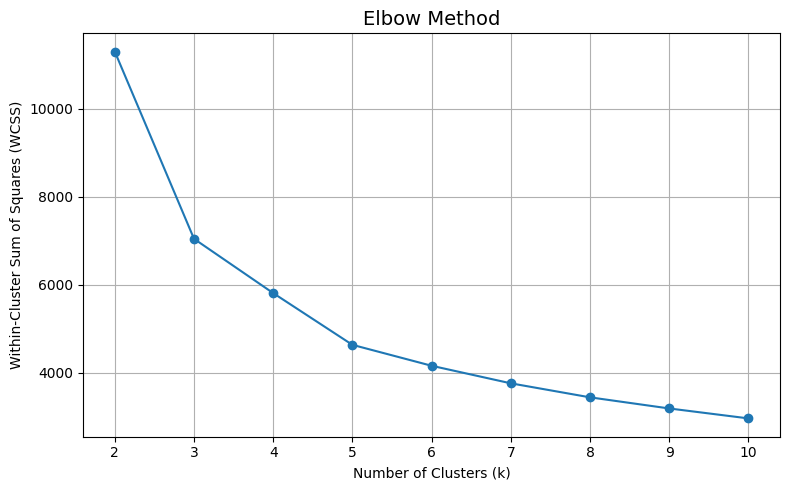

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# ============================================
# STEP 4: Determine the optimal number of clusters (Elbow Method)
# ============================================

wcss = []  # Within-Cluster Sum of Squares
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_no_outliers)  # ← CORRECTION HERE
    wcss.append(kmeans.inertia_)

# Plot the Elbow graph
plt.figure(figsize=(8,5))
plt.plot(range(2, 11), wcss, marker='o')
plt.title('Elbow Method', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Save as image
elbow_path = 'elbow_plot.png'
plt.savefig(elbow_path, dpi=300)
files.download(elbow_path)

##<font color = "seagreen">K-means</font>

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm
from sklearn.cluster import KMeans

# ============================================
# STEP 1. Apply KMeans to the dataset WITHOUT outliers
# ============================================
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled_no_outliers)

# STEP 2. Assign cluster labels
df_no_outliers["cluster"] = clusters
print("✅ Cluster added to the original DataFrame (without outliers).")
print(df_no_outliers.head(), "\n")

# ============================================
# NEW: Count males and females per cluster
# ============================================
gender_counts = (
    df_no_outliers
    .groupby(['cluster', 'Sex'])
    .size()
    .unstack(fill_value=0)
    .rename(columns=lambda x: f"n_{x.lower()}")
)
print("📊 Gender counts by cluster:")
print(gender_counts, "\n")

# ============================================
# STEP 3. Prepare a DataFrame for descriptive stats
# ============================================
# Select only numeric feature columns (exclude 'cluster')
numeric_variables = [
    col for col in df_no_outliers.columns
    if col != 'cluster' and np.issubdtype(df_no_outliers[col].dtype, np.number)
]

df_clustered = df_no_outliers[numeric_variables + ['cluster']].copy()

# ============================================
# STEP 4. Display cluster sizes
# ============================================
print("📊 Cluster Sizes:")
print(df_clustered['cluster'].value_counts().sort_index(), "\n")

# ============================================
# STEP 5. Compute Descriptive Statistics per Cluster
#   – count, mean, median, std, min, max, and 95% CI on raw values
# ============================================
grouped = df_clustered.groupby('cluster')

# Basic stats
count_df  = grouped.size().rename("n").to_frame()
mean_df   = grouped[numeric_variables].mean().add_suffix("_mean")
median_df = grouped[numeric_variables].median().add_suffix("_median")
std_df    = grouped[numeric_variables].std().add_suffix("_std")
min_df    = grouped[numeric_variables].min().add_suffix("_min")
max_df    = grouped[numeric_variables].max().add_suffix("_max")

# 95% CI for the mean
z = norm.ppf(0.975)
ns     = grouped.size().to_frame("n")
se_df  = std_df.values / np.sqrt(ns.values)  # standard errors
ci_lower = mean_df.values - z * se_df
ci_upper = mean_df.values + z * se_df

# Build CI columns
ci_columns = {}
for i, col in enumerate(mean_df.columns):
    var = col.replace("_mean", "")
    ci_col = f"{var}_95CI"
    ci_columns[ci_col] = [
        f"{mean_df.iloc[row, i]:.2f} ({ci_lower[row, i]:.2f}–{ci_upper[row, i]:.2f})"
        for row in range(mean_df.shape[0])
    ]

ci_df = pd.DataFrame(ci_columns, index=mean_df.index)

# ============================================
# STEP 6. Concatenate all tables
# ============================================
descriptive_stats = pd.concat(
    [count_df, mean_df, median_df, std_df, min_df, max_df, ci_df],
    axis=1
)

# ============================================
# STEP 7. Display the final descriptive table
# ============================================
pd.set_option('display.max_columns', None)
print("📌 Descriptive Statistics by Cluster (Original Values):")
print(descriptive_stats, "\n")

# ============================================
# STEP 8. Basic descriptive statistics of the full DataFrame
# ============================================
print("📌 Basic Descriptive Statistics (numeric columns):")
print(df_no_outliers.describe().round(2))


✅ Cluster added to the original DataFrame (without outliers).
    Age     Sex  HR  SAP  DAP     T   PosMu Crtitically   NegNu      Risk  \
17   87  Female  68  113   63  36.2  0.4879    moderate  0.4919  moderate   
18   63    Male  70  142   81  36.3  0.4137    moderate  0.5234  moderate   
19   75  Female  75  142   69  36.5  0.4824    moderate  0.4761  moderate   
20   67  Female  70  159   96  36.4  0.3786        high  0.5218  moderate   
21   80  Female  84   84   51  36.1  0.4326    moderate  0.5351  moderate   

    NeutralEta Uncertainty     Csi PriorityColor   TrailED Hospitalization  \
17      0.0221     veryLow  0.5210         green  returnED              no   
18      0.0651     veryLow  0.4580        yellow  returnED              no   
19      0.0434     veryLow  0.5183         green  returnED              no   
20      0.1017     veryLow  0.4275          blue  returnED              no   
21      0.0345     veryLow  0.4736        yellow  returnED              no   

    cl

##<font color = "seagreen">Silhouette Score</font>

In [ ]:
from sklearn.metrics import silhouette_score

# Computation of the Silhouette Coefficient using data without outliers
sil_score = silhouette_score(X_scaled_no_outliers, clusters)

print(f"\nMean Silhouette Score: {sil_score:.4f}")

# Qualitative interpretation based on established thresholds
if sil_score >= 0.70:
    print("Interpretation: The clustering structure exhibits excellent separation among clusters.")
elif sil_score >= 0.50:
    print("Interpretation: The clustering shows good separation between clusters.")
elif sil_score >= 0.30:
    print("Interpretation: The clustering reveals moderate structure, with some degree of overlap.")
else:
    print("Interpretation: The clustering may lack clear definition and structure.")



Mean Silhouette Score: 0.4268
Interpretation: The clustering reveals moderate structure, with some degree of overlap.


#<font color = "tomato">PCA Projection for Visualization</font>

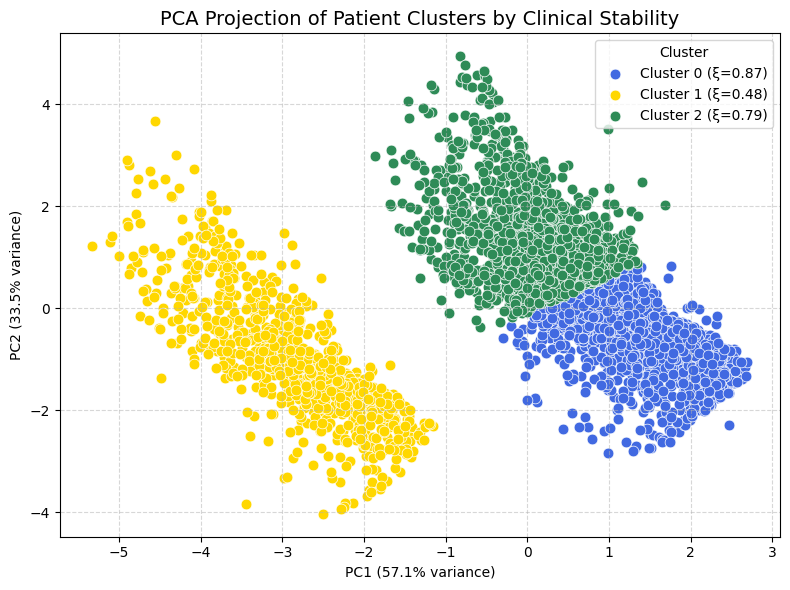

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# ============================================
# 9) PCA projection for visualization
# ============================================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_no_outliers)
explained_var = pca.explained_variance_ratio_ * 100

# Build a plotting DataFrame directly from df_no_outliers
plot_df = df_no_outliers.copy()
plot_df['PC1'] = X_pca[:, 0]
plot_df['PC2'] = X_pca[:, 1]

# Compute mean ξ (Csi) per cluster
mean_xi = plot_df.groupby('cluster')['Csi'].mean().round(2)

# Determine cluster‐color mapping by descending mean ξ
sorted_clusters = mean_xi.sort_values(ascending=False).index.tolist()
palette = ['royalblue', 'seagreen', 'gold']  # map highest→lowest ξ
cluster_colors = {cl: palette[i] for i, cl in enumerate(sorted_clusters)}

# ============================================
# 10) Scatterplot with customized legend
# ============================================
plt.figure(figsize=(8, 6))
for cl, grp in plot_df.groupby('cluster'):
    plt.scatter(
        grp['PC1'], grp['PC2'],
        s=60,
        color=cluster_colors[cl],
        edgecolor='white',
        linewidth=0.5,
        label=f"Cluster {cl} (ξ={mean_xi[cl]:.2f})"
    )

plt.title('PCA Projection of Patient Clusters by Clinical Stability', fontsize=14)
plt.xlabel(f'PC1 ({explained_var[0]:.1f}% variance)')
plt.ylabel(f'PC2 ({explained_var[1]:.1f}% variance)')
plt.legend(title='Cluster', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()




##<font color = "seagreen">Quality Analysis of PCA</font>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from scipy.stats import f_oneway

# ====================================================
# Align feature DataFrame to the outlier‑filtered rows
# ====================================================
# 'features' is the list of numeric columns you used earlier
df_num_no_outliers = df_no_outliers[features].copy()

# Sanity check
assert df_num_no_outliers.shape[0] == X_scaled_no_outliers.shape[0], \
       "Row mismatch between df_num_no_outliers and X_scaled_no_outliers"
assert df_num_no_outliers.shape[1] == X_scaled_no_outliers.shape[1], \
       "Column mismatch between df_num_no_outliers and X_scaled_no_outliers"

# ====================================================
# STEP 1: Manual initialization of centroids
# ====================================================
rng = np.random.RandomState(42)
k = 3
initial_idx = rng.choice(X_scaled_no_outliers.shape[0], size=k, replace=False)
initial_centers = X_scaled_no_outliers[initial_idx]

print("Initial cluster centers:")
print(pd.DataFrame(initial_centers, columns=features).round(4))
print("…\n")

# ====================================================
# STEP 2: Fit KMeans with manual init and verbose
# ====================================================
kmeans = KMeans(
    n_clusters=k,
    init=initial_centers,
    n_init=1,
    max_iter=300,
    random_state=42,
    verbose=1
)
kmeans.fit(X_scaled_no_outliers)

# ====================================================
# STEP 3: Iteration history printed by verbose=1
# ====================================================

# ====================================================
# STEP 4: Final centers and iteration count
# ====================================================
final_centers = kmeans.cluster_centers_
print(f"\nConverged in {kmeans.n_iter_} iterations.")
print("Final cluster centers:")
print(pd.DataFrame(final_centers, columns=features).round(4))
print("\n")

# ====================================================
# STEP 5: Distances between final cluster centers
# ====================================================
dist_matrix = cdist(final_centers, final_centers)
dist_df = pd.DataFrame(
    dist_matrix,
    index=[f"Cluster {i}" for i in range(k)],
    columns=[f"Cluster {i}" for i in range(k)]
)
print("Pairwise distances between final cluster centers:")
print(dist_df.round(4))
print("\n")

# ====================================================
# STEP 6: ANOVA for each clustering variable
# ====================================================
anova_results = []
for col in features:
    groups = [
        df_no_outliers[df_no_outliers['cluster'] == i][col]
        for i in range(k)
    ]
    stat, p = f_oneway(*groups)
    anova_results.append({
        'Variable': col,
        'F-statistic': round(stat, 4),
        'p-value': round(p, 4)
    })

anova_df = pd.DataFrame(anova_results).set_index('Variable')
print("ANOVA results by variable:")
print(anova_df)


Initial cluster centers:
      SAP     DAP   PosMu   NegNu  NeutralEta     Csi
0  1.1731  1.1764  0.2977 -0.5889      0.9434  0.3325
1  0.1322  1.4251  0.2450 -0.3321      0.2615  0.2542
2  1.0482  0.9276  0.0795 -0.2637      0.6118  0.0938
…

Initialization complete
Iteration 0, inertia 29144.738264137104.
Iteration 1, inertia 11642.894637853324.
Iteration 2, inertia 7587.764588352585.
Iteration 3, inertia 7159.035299913904.
Iteration 4, inertia 7088.015072925873.
Iteration 5, inertia 7060.904929732569.
Iteration 6, inertia 7050.577422258719.
Iteration 7, inertia 7046.517840999368.
Iteration 8, inertia 7044.068304160117.
Iteration 9, inertia 7042.935510724683.
Iteration 10, inertia 7042.698095776005.
Converged at iteration 10: center shift 2.307974908053136e-05 within tolerance 8.989284665242513e-05.

Converged in 11 iterations.
Final cluster centers:
      SAP     DAP   PosMu   NegNu  NeutralEta     Csi
0  0.7606  0.7033  0.1930 -0.3962      0.6573  0.2073
1 -0.5919 -0.5625  0.7228 -

##<font color = "seagreen">PCA Metrics</font>

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=e1038f366e4b2053d11a4c6e68cd0838f0e444a9ce791455e52fe90afe3901eb
  Stored in directory: /root/.cache/pip/wheels/fa/f7/53/a55a8a56668a6fe0199e0e02b6e0ae3007ec35cdf6e4c25df7
Successfully built factor_analyzer
Correlation Matrix:
              SAP    DAP  PosMu  NegNu  NeutralEta    Csi
SAP         1.000  0.640 -0.166 -0.004       0.737 -0.147
DAP         0.640  1.000 -0.177  0.020       0.686 -0.160
PosMu      -0.166 -0.177  1.000 -0.973      -0.293  0.999
NegNu      -0.004  0.020 -0.973  1.000       0.065 -0.977
NeutralEta  0.737  0.686 -0.293  0.065       1.000 -0.271
Csi        -0.147 -0.160  0.999 -0.977      -0.271  1.000


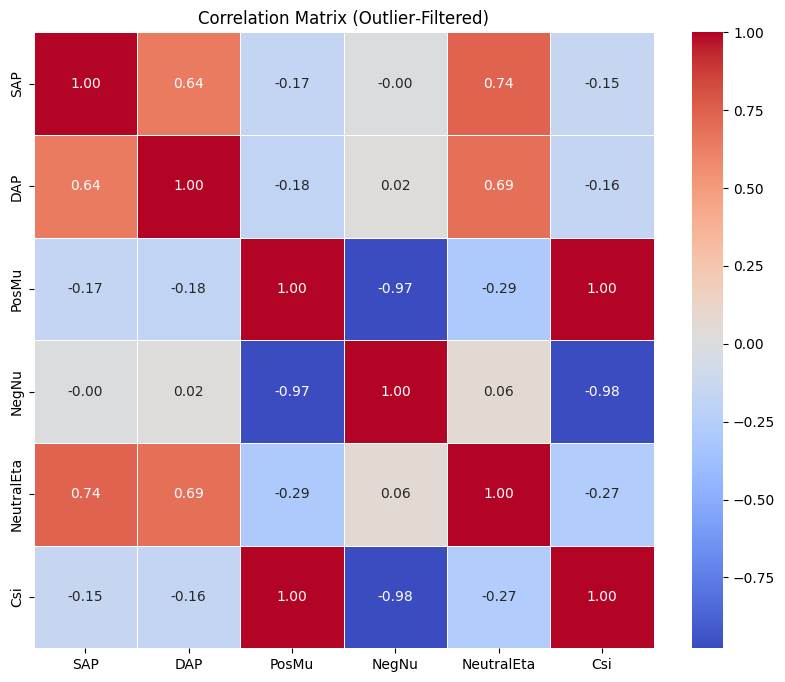


Bartlett’s test chi-square = 69496.33, p-value = 0.0000

KMO per variable:
SAP           0.927
DAP           0.924
PosMu         0.525
NegNu         0.499
NeutralEta    0.379
Csi           0.972
dtype: float64

Overall KMO: 0.607

Anti-Image Correlation Matrix:
              SAP    DAP  PosMu  NegNu  NeutralEta    Csi
SAP         1.000  0.268 -0.005  0.013       0.053  0.063
DAP         0.268  1.000 -0.001  0.014       0.045  0.055
PosMu      -0.005 -0.001  1.000 -0.958      -0.962  0.212
NegNu       0.013  0.014 -0.958  1.000      -0.997 -0.077
NeutralEta  0.053  0.045 -0.962 -0.997       1.000 -0.052
Csi         0.063  0.055  0.212 -0.077      -0.052  1.000


/usr/local/lib/python3.11/dist-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


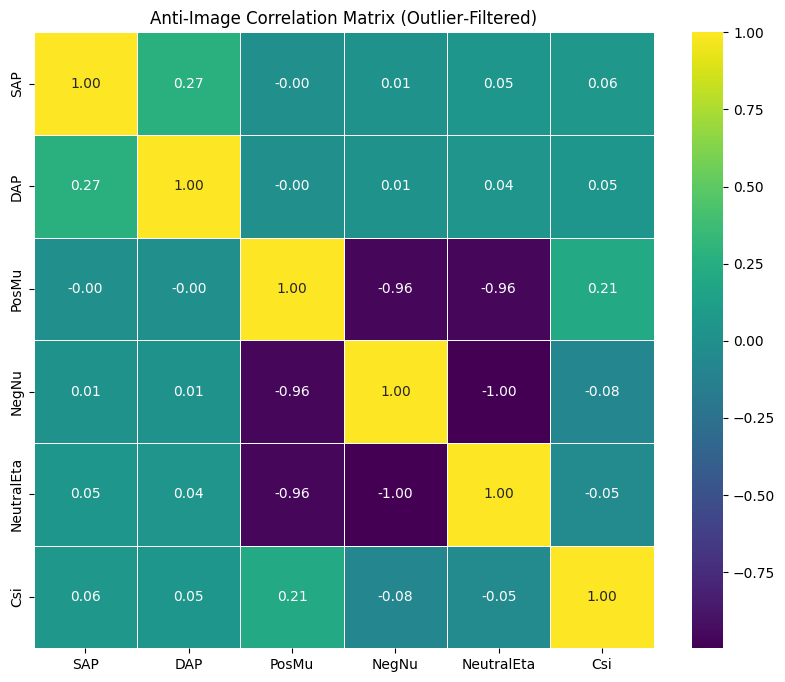

In [ ]:
!pip install factor_analyzer

import pandas as pd
import numpy as np
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================
# Prepare data: df_num_no_outliers contains the numeric features used for clustering (outlier‑filtered)
# ============================================

# 1) Correlation matrix
corr_matrix = df_num_no_outliers.corr()
print("Correlation Matrix:")
print(corr_matrix.round(3))

# Optional: visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix (Outlier‑Filtered)")
plt.show()

# 2) Bartlett’s Test of Sphericity
chi2, bartlett_p = calculate_bartlett_sphericity(df_num_no_outliers)
print(f"\nBartlett’s test chi-square = {chi2:.2f}, p-value = {bartlett_p:.4f}")

# 3) Kaiser-Meyer-Olkin (KMO) Test
kmo_per_item, kmo_overall = calculate_kmo(df_num_no_outliers)
kmo_results = pd.Series(kmo_per_item, index=df_num_no_outliers.columns)
print(f"\nKMO per variable:")
print(kmo_results.round(3))
print(f"\nOverall KMO: {kmo_overall:.3f}")

# 4) Anti-Image Correlation Matrix
#    Anti-image correlations are the negatives of the partial correlations
inv_corr = np.linalg.inv(corr_matrix.values)
d = np.sqrt(np.diag(inv_corr))
partial_corr = -inv_corr / np.outer(d, d)
np.fill_diagonal(partial_corr, 1.0)
anti_image_corr = pd.DataFrame(partial_corr,
                               index=df_num_no_outliers.columns,
                               columns=df_num_no_outliers.columns)
print("\nAnti-Image Correlation Matrix:")
print(anti_image_corr.round(3))

# Optional: visualize the anti-image correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(anti_image_corr, annot=True, fmt=".2f", cmap="viridis", linewidths=0.5)
plt.title("Anti-Image Correlation Matrix (Outlier‑Filtered)")
plt.show()


##<font color = "seagreen">Cluster Robustness and Clinical Validation</font>

Calinski–Harabasz Index: 809.87
Davies–Bouldin   Index: 1.18

→ Higher Calinski–Harabasz means better cluster separation.
→ Lower Davies–Bouldin means more compact, distinct clusters.

Bootstrap Stability (n=50):
  Mean ARI = 0.759
  Std  ARI = 0.292

→ ARI close to 1.0 indicates highly stable clustering.



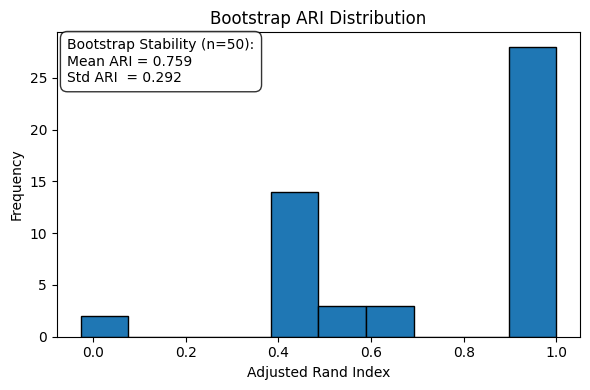

In [ ]:
# ------------------------------------------------------------------------------
# 5) WHITENING TRANSFORMATION AND K‑MEANS CLUSTERING
# ------------------------------------------------------------------------------

from scipy.linalg import sqrtm
from sklearn.cluster import KMeans

# 5.1. Select numeric features (if not already done)
numeric_df = df_num_no_outliers.select_dtypes(include=[np.number]).copy()
X = numeric_df.values

# 5.2. Compute whitening matrix
cov_matrix   = np.cov(X, rowvar=False)
inv_cov      = np.linalg.inv(cov_matrix)
whitening_mat = sqrtm(inv_cov)

# 5.3. Apply whitening
X_whitened = X.dot(whitening_mat)

# 5.4. Run K‑means with fixed seed
n_clusters  = 3
random_seed = 42

kmeans = KMeans(
    n_clusters=n_clusters,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=random_seed
)
labels = kmeans.fit_predict(X_whitened)

# 5.5. Attach cluster labels back to the DataFrame
df_num_no_outliers['cluster'] = labels


# ------------------------------------------------------------------------------
# 6) CLUSTER VALIDITY INDICES: Calinski–Harabasz & Davies–Bouldin
# ------------------------------------------------------------------------------

from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

ch_index = calinski_harabasz_score(X_whitened, labels)
db_index = davies_bouldin_score(X_whitened, labels)

print(f"Calinski–Harabasz Index: {ch_index:.2f}")
print(f"Davies–Bouldin   Index: {db_index:.2f}")
print(
    "\n→ Higher Calinski–Harabasz means better cluster separation.\n"
    "→ Lower Davies–Bouldin means more compact, distinct clusters.\n"
)


# ------------------------------------------------------------------------------
# 7) BOOTSTRAP-BASED STABILITY ANALYSIS (ARI)
# ------------------------------------------------------------------------------

from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt

n_bootstraps = 50
sample_frac  = 0.80
ari_scores   = []

np.random.seed(random_seed)
for i in range(n_bootstraps):
    # sample indices with replacement
    idx = np.random.choice(
        X_whitened.shape[0],
        size=int(sample_frac * X_whitened.shape[0]),
        replace=True
    )
    X_bs        = X_whitened[idx]
    true_labels = labels[idx]

    # recluster the bootstrap sample
    kmeans_bs = KMeans(
        n_clusters=n_clusters,
        init='k-means++',
        n_init=10,
        max_iter=300,
        random_state=random_seed
    ).fit(X_bs)
    labels_bs = kmeans_bs.labels_

    # compute Adjusted Rand Index
    ari = adjusted_rand_score(true_labels, labels_bs)
    ari_scores.append(ari)

ari_mean = np.mean(ari_scores)
ari_std  = np.std(ari_scores)

print(
    f"Bootstrap Stability (n={n_bootstraps}):\n"
    f"  Mean ARI = {ari_mean:.3f}\n"
    f"  Std  ARI = {ari_std:.3f}\n"
)
print("→ ARI close to 1.0 indicates highly stable clustering.\n")

# 7.4. Plot ARI distribution with summary annotation
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.hist(ari_scores, bins=10, edgecolor='k')
plt.title("Bootstrap ARI Distribution")
plt.xlabel("Adjusted Rand Index")
plt.ylabel("Frequency")

# Add text box with summary statistics
textstr = (
    f"Bootstrap Stability (n={n_bootstraps}):\n"
    f"Mean ARI = {ari_mean:.3f}\n"
    f"Std ARI  = {ari_std:.3f}"
)
# place a text box in upper left in axes coords
plt.gca().text(
    0.02, 0.98, textstr,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8)
)

plt.tight_layout()
plt.show()



##<font color = "seagreen">Communalities</font>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ============================================
# Prepare the standardized data for communalities
# ============================================
# Use the outlier‑filtered feature set
features = df_num_no_outliers.columns.tolist()

scaler = StandardScaler()
X_std = scaler.fit_transform(df_num_no_outliers[features])

# ============================================
# STEP 1: Initial communalities = 1 for all variables
# ============================================
initial_comm = pd.Series(1.0, index=features, name='Initial Communality')

# ============================================
# STEP 2: PCA on standardized data (correlation PCA)
# ============================================
n_components = 2
pca = PCA(n_components=n_components, random_state=42)
pca.fit(X_std)

# ============================================
# STEP 3: Compute loadings: component weights × sqrt(eigenvalues)
# explained_variance_ * n_features = eigenvalues of the correlation matrix
# ============================================
eigenvalues = pca.explained_variance_ratio_ * len(features)
loadings = pca.components_.T * np.sqrt(eigenvalues)

# ============================================
# STEP 4: Extracted communalities = sum of squared loadings per variable
# ============================================
extracted_comm = pd.Series(
    np.sum(loadings**2, axis=1),
    index=features,
    name=f'Communality (first {n_components} PCs)'
)

# ============================================
# STEP 5: Combine and display communalities
# ============================================
communalities_df = pd.concat([initial_comm, extracted_comm], axis=1)
print("\n📌 Variable Communalities:")
print(communalities_df.round(3))





📌 Variable Communalities:
       Initial Communality  Communality (first 2 PCs)
SAP                    1.0                      0.824
DAP                    1.0                      0.822
NegNu                  1.0                      0.992
Csi                    1.0                      0.991


##<font color = "seagreen">Eigenvalues</font>

In [ ]:
import pandas as pd
from sklearn.decomposition import PCA

# ============================================
# STEP 1: Fit PCA on the outlier‑filtered, standardized data
# ============================================
# One component per original variable
pca_full = PCA(n_components=X_scaled_no_outliers.shape[1], random_state=42)
pca_full.fit(X_scaled_no_outliers)

# ============================================
# STEP 2: Build a DataFrame of eigenvalues and explained variances
# ============================================
eigen_df = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(pca_full.explained_variance_))],
    'Eigenvalue': pca_full.explained_variance_,
    'Variance (%)': pca_full.explained_variance_ratio_ * 100,
    'Cumulative Variance (%)': (pca_full.explained_variance_ratio_ * 100).cumsum()
})

# ============================================
# STEP 3: Round and display
# ============================================
print("📊 Eigenvalues and Explained Variance (on outlier‑filtered data):")
print(eigen_df.round(1))


📊 Eigenvalues and Explained Variance (on outlier‑filtered data):
  Principal Component  Eigenvalue  Variance (%)  Cumulative Variance (%)
0                 PC1         2.0          53.4                     53.4
1                 PC2         1.4          37.9                     91.3
2                 PC3         0.3           8.3                     99.5
3                 PC4         0.0           0.5                    100.0


##<font color = "seagreen">Ortogonal Rotation</font>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def varimax(Phi, gamma=1.0, q=100, tol=1e-6):
    """
    Perform Varimax (orthogonal) rotation on a loading matrix Phi.
    Phi: (p × k) matrix of loadings.
    Returns the rotated matrix of the same shape.
    """
    p, k = Phi.shape
    R = np.eye(k)
    d = 0
    for _ in range(q):
        Lambda = Phi @ R
        u, s, vh = np.linalg.svd(
            Phi.T @ (Lambda**3
                     - (gamma / p) * Lambda * np.sum(Lambda**2, axis=0))
        )
        R_new = u @ vh
        d_new = s.sum()
        if d_new - d < tol:
            break
        R = R_new
        d = d_new
    return Phi @ R

# ============================================
# 0) Build the filtered feature DataFrame
# ============================================
# 'features' was defined earlier as the list of numeric columns used
df_feat = df_no_outliers[features].copy()

# ============================================
# 1) Standardize the data
# ============================================
scaler = StandardScaler()
X_std = scaler.fit_transform(df_feat)

# ============================================
# 2) PCA extraction (first two components)
# ============================================
pca = PCA(n_components=2, random_state=42)
pca.fit(X_std)

# Compute the unrotated loadings = weights × sqrt(eigenvalues)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# ============================================
# 3) Varimax rotation
# ============================================
rotated_loadings = varimax(loadings)

# ============================================
# 4) Display rotated loadings
# ============================================
loadings_df = pd.DataFrame(
    rotated_loadings,
    index=features,
    columns=['Factor 1', 'Factor 2']
)

print("Varimax‑Rotated Factor Loadings:")
print(loadings_df.round(3))


Varimax‑Rotated Factor Loadings:
       Factor 1  Factor 2
SAP      -0.033     0.907
DAP      -0.055     0.905
NegNu    -0.995    -0.045
Csi       0.988    -0.122


##<font color = "seagreen">PCA Loading Map</font>

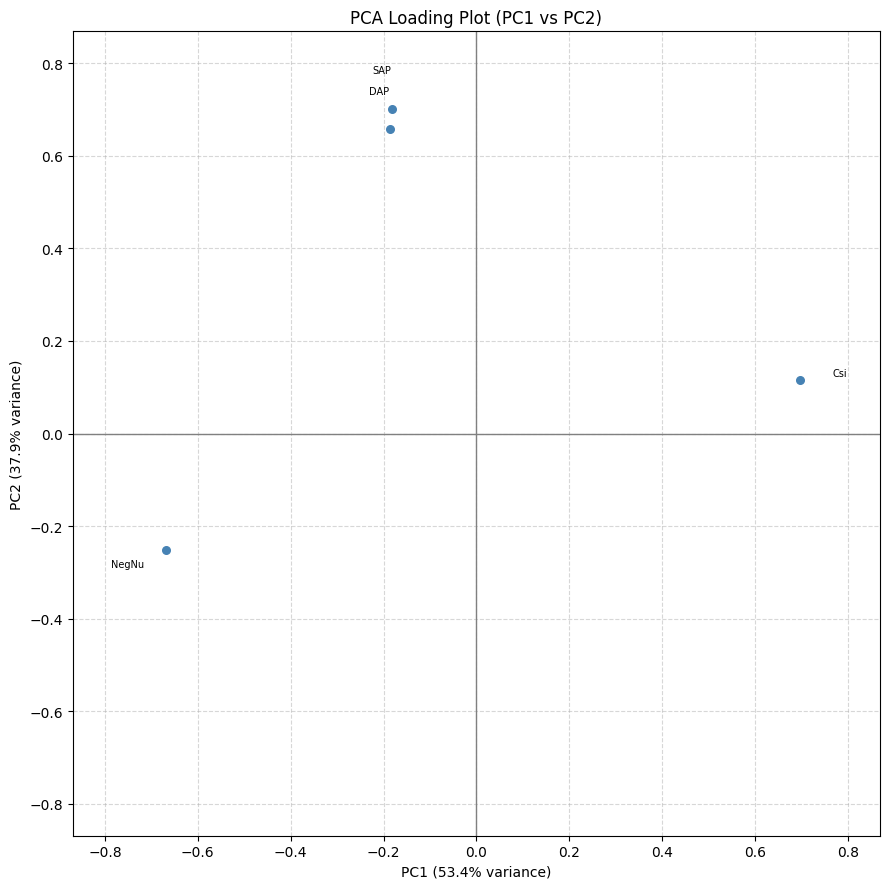

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ============================================
# 0) Align your feature DataFrame to the rows used in X_scaled_no_outliers
# ============================================
# Assume df_original_no_outliers has exactly the same rows as #X_scaled_no_outliers
#columns_to_drop = ['ID','NeuroAC', 'Dplus', 'Dminus', 'RankTOPSIS', #'StayHour', 'ReturnED', 'cluster']
#df_num_no_outliers = df_original_no_outliers.select_dtypes(include='number') \
#                                             .drop(columns=columns_to_drop)

# ============================================
# 1) Skip re-standardizing—use your precomputed X_scaled_no_outliers
# ============================================
# X_scaled_no_outliers was obtained by StandardScaler on df_num_no_outliers

# ============================================
# 2) Perform PCA on the outlier-filtered data
# ============================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_no_outliers)    # use the same object you used for plotting
loadings = pca.components_.T                       # (variables × PCs)
loading_df = pd.DataFrame(loadings,
                          index=df_num_no_outliers.columns,
                          columns=['PC1','PC2'])

# ============================================
# 3) Plot loading plot
# ============================================
plt.figure(figsize=(9,9))
plt.axhline(0, color='grey', linewidth=1)
plt.axvline(0, color='grey', linewidth=1)

# Scatter the loadings
plt.scatter(loading_df['PC1'], loading_df['PC2'], s=30, color='steelblue')

# Radial offset
max_radius = np.hypot(loading_df['PC1'], loading_df['PC2']).max()
offset = max_radius * 0.12

# Annotate without boxes
for var, (x, y) in loading_df.iterrows():
    r = np.hypot(x, y)
    dx, dy = (offset * x/r, offset * y/r) if r>0 else (offset, offset)
    plt.text(x+dx, y+dy, var, fontsize=7, ha='center', va='center')

# Labels and title with the correct explained variances
explained = pca.explained_variance_ratio_ * 100
plt.xlabel(f"PC1 ({explained[0]:.1f}% variance)")
plt.ylabel(f"PC2 ({explained[1]:.1f}% variance)")
plt.title("PCA Loading Plot (PC1 vs PC2)")
plt.grid(True, linestyle='--', alpha=0.5)

lim = max_radius * 1.2
plt.xlim(-lim, lim)
plt.ylim(-lim, lim)

plt.tight_layout()
plt.show()




In [ ]:
# ============================================
# STEP 9: Export the clustered results to Excel
# ============================================
from google.colab import files

exported_file = "cluster_results.xlsx"
# df_no_outliers contains the outlier‑filtered patients plus the 'cluster' column
df_no_outliers.to_excel(exported_file, index=False, engine='openpyxl')

print(f"✅ Cluster results saved to: {exported_file}")
files.download(exported_file)


✅ Cluster results saved to: cluster_results.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##<font color = "seagreen">Cluster Descriptives</font>

📌 Descriptive Statistics by Cluster:
            Age                                                 HR         \
          count   mean   std   min   25%   50%   75%   max   count   mean   
cluster                                                                     
0         909.0  71.67  7.38  60.0  66.0  71.0  77.0  95.0   909.0  82.18   
1        1461.0  72.66  7.53  60.0  67.0  72.0  78.0  98.0  1461.0  83.42   
2        1724.0  72.49  7.47  60.0  67.0  72.0  78.0  99.0  1724.0  81.95   

                                                  SAP                        \
           std   min   25%   50%   75%    max   count    mean    std    min   
cluster                                                                       
0        14.45  49.0  72.0  81.0  92.0  139.0   909.0  135.79  23.02   77.0   
1        15.94  25.0  73.0  82.0  94.0  183.0  1461.0  155.56  17.15  115.0   
2        14.95  30.0  72.0  81.0  91.0  200.0  1724.0  121.82  14.09   77.0   

                         

/tmp/ipython-input-28-2944922588.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_no_outliers, x='cluster', y=var, palette='Set2')


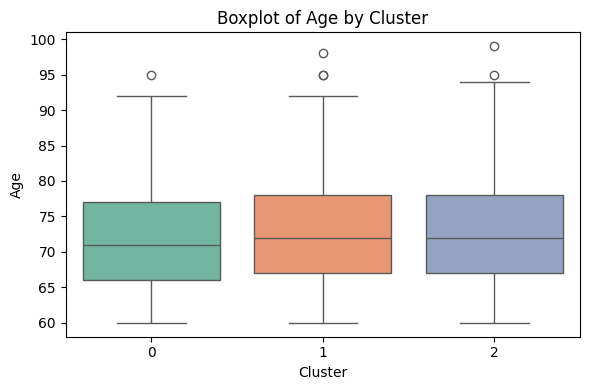

/tmp/ipython-input-28-2944922588.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_no_outliers, x='cluster', y=var, palette='Set2')


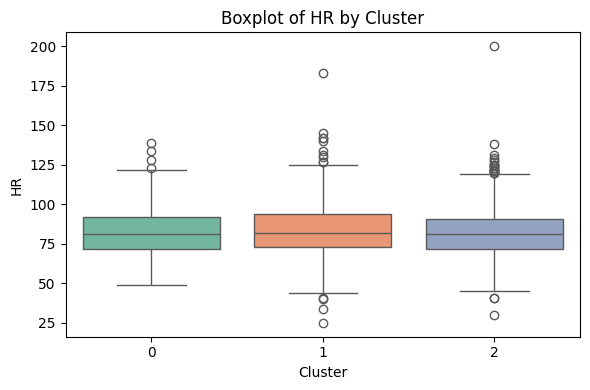

/tmp/ipython-input-28-2944922588.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_no_outliers, x='cluster', y=var, palette='Set2')


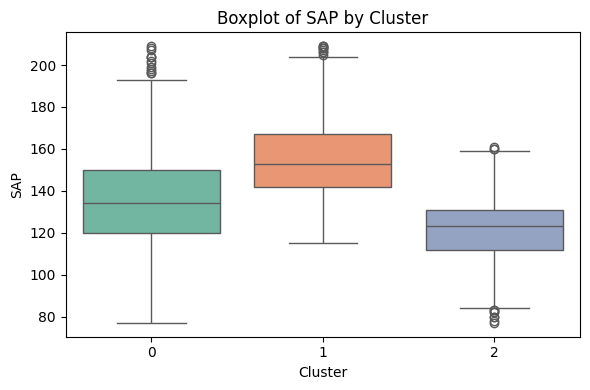

/tmp/ipython-input-28-2944922588.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_no_outliers, x='cluster', y=var, palette='Set2')


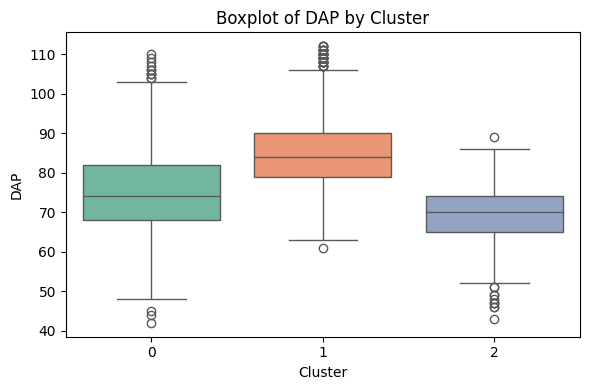

/tmp/ipython-input-28-2944922588.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_no_outliers, x='cluster', y=var, palette='Set2')


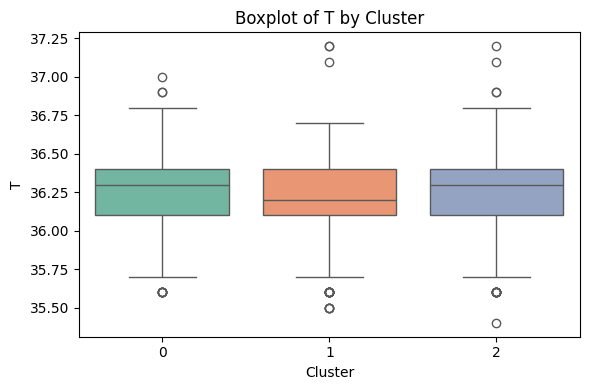

/tmp/ipython-input-28-2944922588.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_no_outliers, x='cluster', y=var, palette='Set2')


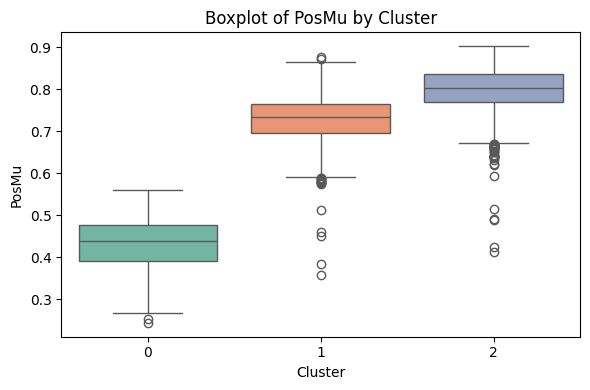

/tmp/ipython-input-28-2944922588.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_no_outliers, x='cluster', y=var, palette='Set2')


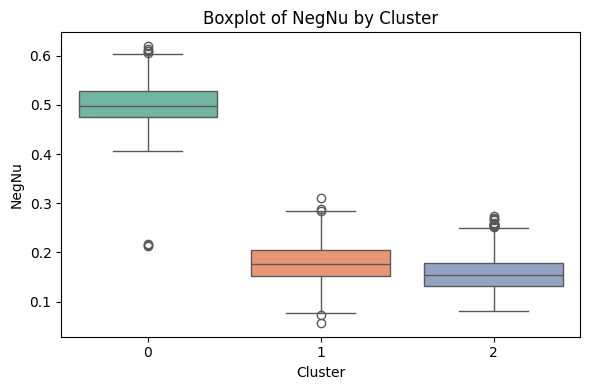

/tmp/ipython-input-28-2944922588.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_no_outliers, x='cluster', y=var, palette='Set2')


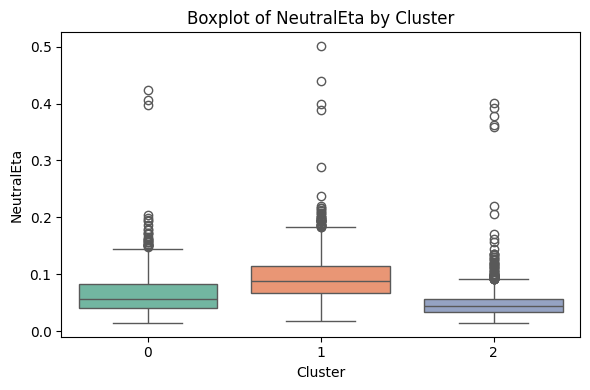

/tmp/ipython-input-28-2944922588.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_no_outliers, x='cluster', y=var, palette='Set2')


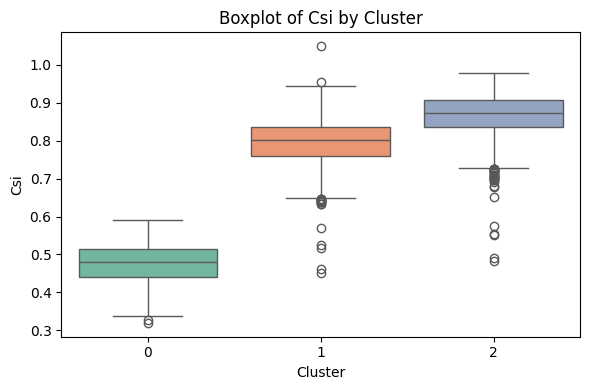

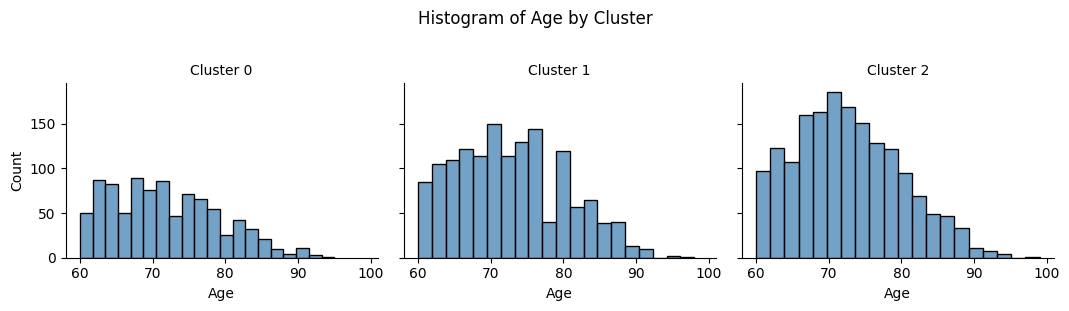

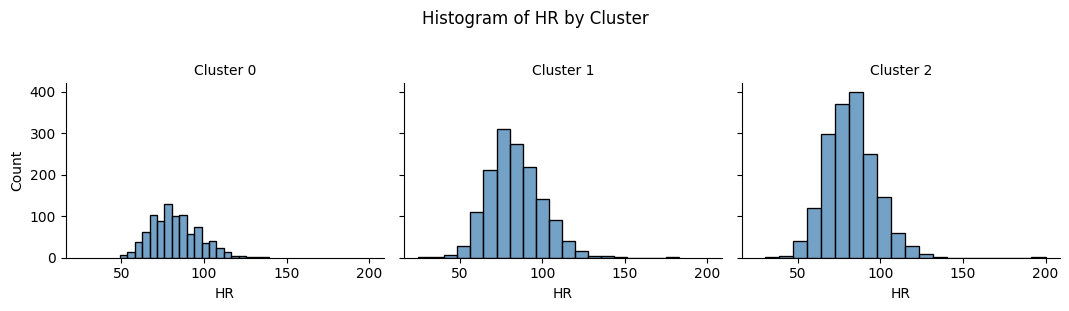

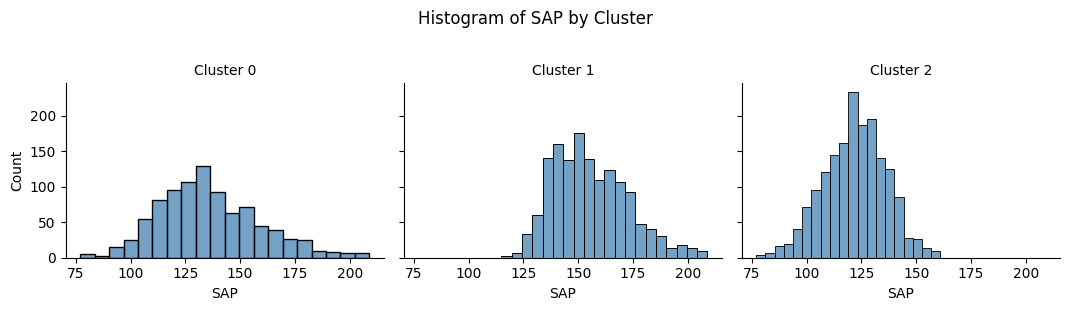

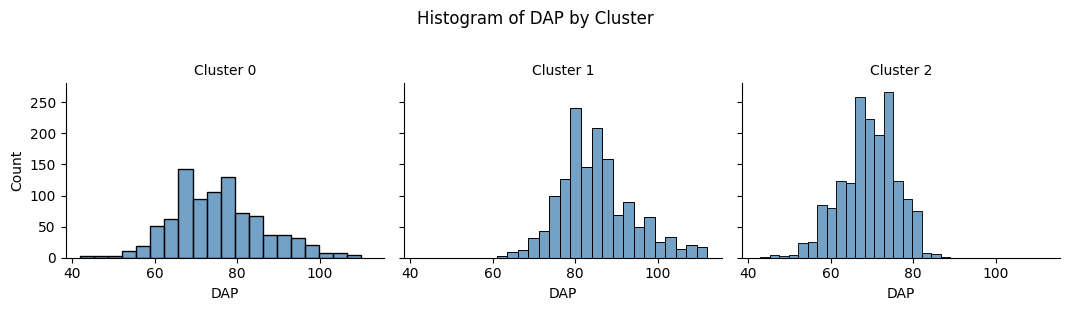

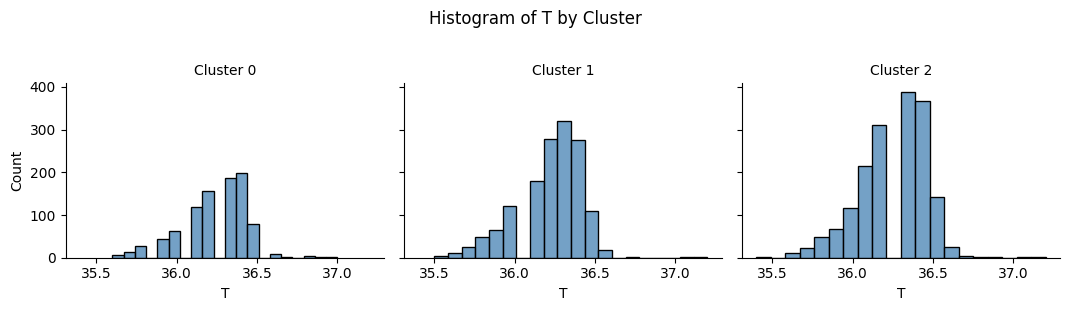

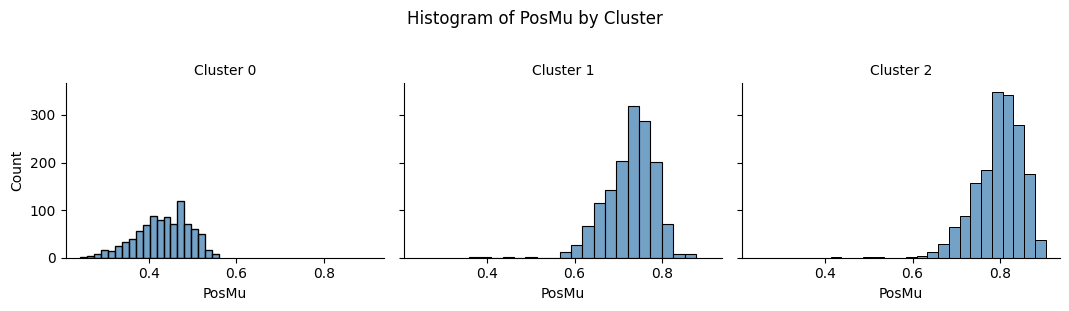

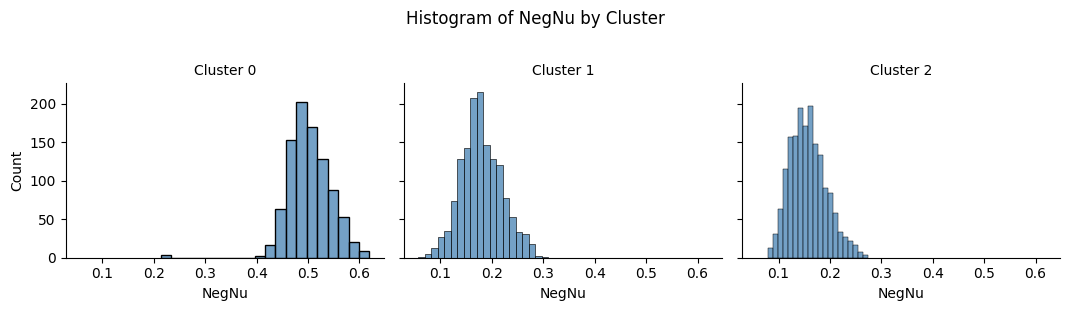

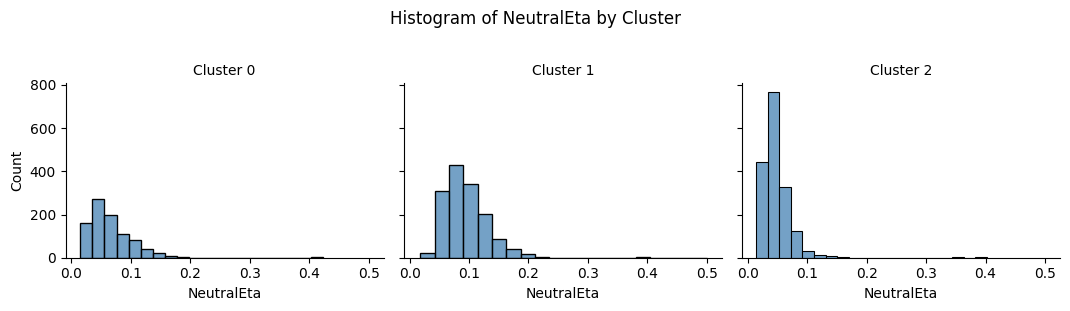

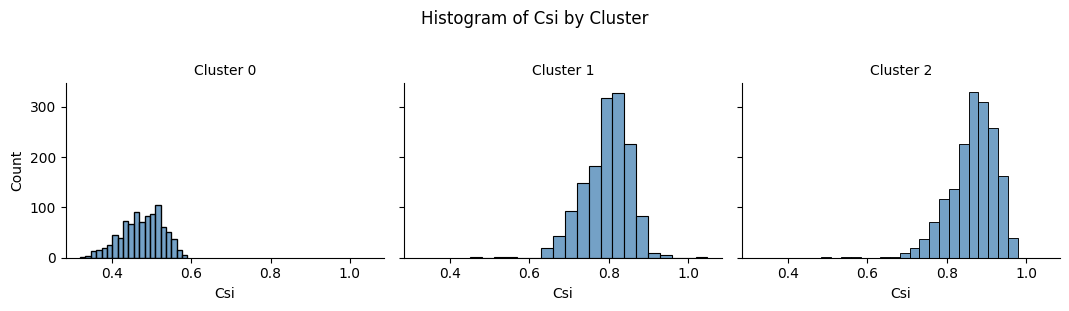

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# Prepare Data
# ============================================
# df_no_outliers: DataFrame with numeric features + 'cluster'
# Select numeric variables (exclude 'cluster')
numeric_vars = [col for col in df_no_outliers.columns
                if col != 'cluster' and pd.api.types.is_numeric_dtype(df_no_outliers[col])]

# ============================================
# 1) Descriptive Statistics by Cluster
# ============================================
desc_stats = df_no_outliers.groupby('cluster')[numeric_vars].describe().round(2)
print("📌 Descriptive Statistics by Cluster:")
print(desc_stats)

# ============================================
# 2) Boxplots for Each Numeric Variable by Cluster
# ============================================
for var in numeric_vars:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df_no_outliers, x='cluster', y=var, palette='Set2')
    plt.title(f'Boxplot of {var} by Cluster')
    plt.xlabel('Cluster')
    plt.ylabel(var)
    plt.tight_layout()
    plt.show()

# ============================================
# 3) Histograms of Each Numeric Variable Faceted by Cluster
# ============================================
for var in numeric_vars:
    g = sns.FacetGrid(df_no_outliers, col='cluster', height=3, aspect=1.2, col_wrap=3)
    g.map_dataframe(sns.histplot, x=var, bins=20, kde=False, color='steelblue', edgecolor='black')
    g.set_titles("Cluster {col_name}")
    g.set_axis_labels(var, "Count")
    plt.suptitle(f'Histogram of {var} by Cluster', y=1.02)
    plt.tight_layout()
    plt.show()

##<font color = "seagreen">Kruskal–Wallis Test by Variable</font>




In [ ]:
from scipy.stats import kruskal
import pandas as pd

# ============================================
# Kruskal–Wallis Tests by Variable
# ============================================
print("\n📊 Kruskal–Wallis Tests by Variable:\n")

test_results = []
numeric_vars = [col for col in df_no_outliers.columns
                if col != 'cluster' and pd.api.types.is_numeric_dtype(df_no_outliers[col])]

for col in numeric_vars:
    groups = [
        df_no_outliers[df_no_outliers['cluster'] == cl][col].dropna()
        for cl in sorted(df_no_outliers['cluster'].unique())
    ]
    stat, p = kruskal(*groups)
    test_results.append({
        "Variable": col,
        "H_statistic": round(stat, 3),
        "p_value": round(p, 4),
        "Significant (p<0.05)": "Yes" if p < 0.05 else "No"
    })

df_results = pd.DataFrame(test_results).sort_values(by="p_value").reset_index(drop=True)
print(df_results.to_string(index=False))

# ✅ Interpretative Note
print("\n📌 Interpretation of Results:")
print("Variables with p < 0.05 indicate that their distributions differ significantly across clusters.")
print("Variables with p ≥ 0.05 show no statistically significant difference among clusters.")




📊 Kruskal–Wallis Tests by Variable:

  Variable  H_statistic  p_value Significant (p<0.05)
       DAP     1815.574   0.0000                  Yes
       SAP     1909.446   0.0000                  Yes
     NegNu     2273.824   0.0000                  Yes
     PosMu     2749.094   0.0000                  Yes
NeutralEta     1579.860   0.0000                  Yes
       Csi     2706.850   0.0000                  Yes
       Age       11.032   0.0040                  Yes
         T        8.464   0.0145                  Yes
        HR        6.562   0.0376                  Yes

📌 Interpretation of Results:
Variables with p < 0.05 indicate that their distributions differ significantly across clusters.
Variables with p ≥ 0.05 show no statistically significant difference among clusters.


##<font color = "seagreen">Dunn's Post-Hoc Test</font>

In [ ]:
!pip install -q scikit-posthocs

import scikit_posthocs as sp
import pandas as pd

# ============================================
# Dunn’s post-hoc test for Csi by cluster
# ============================================
posthoc = sp.posthoc_dunn(
    df_no_outliers,
    val_col='Csi',
    group_col='cluster',
    p_adjust='bonferroni'
)

# Format the p-values with four decimal places
posthoc_formatted = posthoc.applymap(lambda x: f"{x:.4f}")

print("📌 Dunn’s Post-hoc Test (Bonferroni‑corrected p-values):")
print(posthoc_formatted)

📌 Dunn’s Post-hoc Test (Bonferroni‑corrected p-values):
        0       1       2
0  1.0000  0.0000  0.0000
1  0.0000  1.0000  0.0000
2  0.0000  0.0000  1.0000


/tmp/ipython-input-30-1457420383.py:17: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  posthoc_formatted = posthoc.applymap(lambda x: f"{x:.4f}")


##<font color = "seagreen">Shapiro's Normality Test</font>

In [ ]:
from scipy.stats import shapiro

# ============================================
# Shapiro–Wilk Normality Test by Cluster
# ============================================
variables = ['Age', 'SAP', 'HR', 'DAP', 'Csi', 'NegNu', 'PosMu', 'NeutralEta']

print("\n📊 Shapiro–Wilk Normality Test by Variable and Cluster:\n")
for var in variables:
    for cluster in sorted(df_no_outliers['cluster'].unique()):
        group = df_no_outliers[df_no_outliers['cluster'] == cluster][var].dropna()
        stat, p = shapiro(group)
        print(f"{var:12} | Cluster {cluster}: W = {stat:.3f}, p = {p:.4f}")




📊 Shapiro–Wilk Normality Test by Variable and Cluster:

Age          | Cluster 0: W = 0.966, p = 0.0000
Age          | Cluster 1: W = 0.977, p = 0.0000
Age          | Cluster 2: W = 0.976, p = 0.0000
SAP          | Cluster 0: W = 0.984, p = 0.0000
SAP          | Cluster 1: W = 0.973, p = 0.0000
SAP          | Cluster 2: W = 0.997, p = 0.0007
HR           | Cluster 0: W = 0.985, p = 0.0000
HR           | Cluster 1: W = 0.986, p = 0.0000
HR           | Cluster 2: W = 0.982, p = 0.0000
DAP          | Cluster 0: W = 0.987, p = 0.0000
DAP          | Cluster 1: W = 0.972, p = 0.0000
DAP          | Cluster 2: W = 0.990, p = 0.0000
Csi          | Cluster 0: W = 0.985, p = 0.0000
Csi          | Cluster 1: W = 0.966, p = 0.0000
Csi          | Cluster 2: W = 0.947, p = 0.0000
NegNu        | Cluster 0: W = 0.933, p = 0.0000
NegNu        | Cluster 1: W = 0.994, p = 0.0000
NegNu        | Cluster 2: W = 0.983, p = 0.0000
PosMu        | Cluster 0: W = 0.981, p = 0.0000
PosMu        | Cluster 1: W = 0